# Sample Evolution Analysis

Per-sample trajectory analysis across 1499 training checkpoints.  
Fixed noise seed → same sample index tracks the same noise vector across all epochs.

**4-state classification:**
- 🟠 State 0 — Invalid + quant ambiguous (≥1 bit with |x|<0.1)
- 🔴 State 1 — Invalid + clean quantization (rule error only)
- 🟢 State 2 — Valid novel (not in training set)
- 🟣 State 3 — Valid & Memorized (exact match to a training pattern)

**Figures produced per experiment:**
1. `evolution_overview` — change rate, bits flipped, valid/mem/ambig, 4-state area, confidence, arrival CDF
2. `state_transitions` — stacked area + all 8 inter-state transitions (EMA) + late zoom
3. `state_raster_4state` — per-sample state raster (log-x, sorted by final state)

In [1]:
import os, sys
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# ── repo root on path ──────────────────────────────────────────────────────────
NOTEBOOK_DIR = os.path.abspath('')
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top']   = False
plt.rcParams['figure.dpi'] = 120

SAVEROOT = (
    "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/"
    "DL_Projects/DiffusionParityLearning"
)
FIGDIR = os.path.join(PROJECT_ROOT, 'figures', 'rowK_analysis')
os.makedirs(FIGDIR, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Figure dir:   {FIGDIR}')

Project root: /n/home12/binxuwang/Github/DiffusionAttnConsistency
Figure dir:   /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/rowK_analysis


In [2]:
# ── Import plotting helpers from the script ────────────────────────────────────
# We import directly so changes to the script flow into the notebook automatically.
import importlib, importlib.util

spec = importlib.util.spec_from_file_location(
    'plot_sample_evolution',
    os.path.join(PROJECT_ROOT, 'scripts', 'plot_sample_evolution.py')
)
pse = importlib.util.module_from_spec(spec)
spec.loader.exec_module(pse)

# Re-export helpers into notebook namespace for convenience
ema              = pse.ema
load_data        = pse.load_data
build_state      = pse.build_state
sort_state       = pse.sort_state
pcolormesh_edges = pse.pcolormesh_edges
STATE_INFO       = pse.STATE_INFO
plot_overview    = pse.plot_overview
plot_transitions = pse.plot_transitions
plot_raster      = pse.plot_raster
print('Helpers loaded from scripts/plot_sample_evolution.py')

Helpers loaded from scripts/plot_sample_evolution.py


## Experiments

In [3]:
# All 8 row-K experiments with pre-computed evolution_metrics.npz
EXPS = [
    'DiT_mini_rowK2_n6_N4096',
    'DiT_mini_rowK3_n6_N4096',
    'DiT_mini_rowK4_n6_N4096',
    'DiT_mini_rowK5_n6_N4096',
    'DiT_mini_varK0246_n6_N4096',
    'DiT_mini_varK1345_n6_N4096',
    'DiT_mini_globalK15_n6_N4096',
    'DiT_mini_globalK23_n6_N4096',
]

# Check which ones have evolution_metrics.npz
for exp in EXPS:
    p = os.path.join(SAVEROOT, exp, 'evolution_analysis', 'evolution_metrics.npz')
    status = 'OK' if os.path.exists(p) else 'MISSING'
    print(f'{status:8s}  {exp}')

OK        DiT_mini_rowK2_n6_N4096
OK        DiT_mini_rowK3_n6_N4096
MISSING   DiT_mini_rowK4_n6_N4096
MISSING   DiT_mini_rowK5_n6_N4096
MISSING   DiT_mini_varK0246_n6_N4096
MISSING   DiT_mini_varK1345_n6_N4096
OK        DiT_mini_globalK15_n6_N4096
MISSING   DiT_mini_globalK23_n6_N4096


---
## Section 1 — Overview (one experiment)

6-panel figure: change rate, bits flipped, valid/mem/ambiguous fractions, 4-state stacked area, model confidence, memorization arrival CDF.

In [4]:
EXP = 'DiT_mini_rowK2_n6_N4096'   # ← change to explore other experiments

d = load_data(EXP, SAVEROOT)
print(f"Loaded: {EXP}")
print(f"  epochs:          {d['epochs'].shape}  [{d['epochs'][0]} .. {d['epochs'][-1]}]")
print(f"  is_valid:        {d['is_valid'].shape}")
print(f"  is_mem:          {d['is_mem'].shape}")
print(f"  has_ambiguous:   {d['has_ambiguous'].shape}")
print(f"  arrival_epochs:  {d['arrival_epochs'].shape}  ({(d['arrival_epochs']>=0).sum()} ever seen)")

Loaded: DiT_mini_rowK2_n6_N4096
  epochs:          (1499,)  [1 .. 1000000]
  is_valid:        (1499, 2048)
  is_mem:          (1499, 2048)
  has_ambiguous:   (1499, 2048)
  arrival_epochs:  (4096,)  (2343 ever seen)


In [5]:
plot_overview(d, EXP, FIGDIR)

  Saved: evolution_overview


---
## Section 2 — State Transitions

3-panel figure:
- **Panel 1**: 4-state stacked area (orange=quant-ambig, red=rule-error, green=valid-novel, purple=memorized)
- **Panel 2**: All 8 inter-state transitions, raw (faint, α=0.12) + EMA (bold, α=0.9)
- **Panel 3**: Zoom on late training (step > 100k) to see churn dynamics

In [6]:
plot_transitions(d, EXP, FIGDIR)

  Saved: state_transitions


---
## Section 3 — Per-Sample State Raster

Each row = one sample (same noise seed tracked across all training steps).  
Sorted by: final state (memorized at top) → first epoch memorized → first epoch valid.  
x-axis is log-scaled training step; cell width computed correctly using pcolormesh + log-space edges.

In [7]:
plot_raster(d, EXP, FIGDIR)

  Saved: state_raster_4state


---
## Section 4 — Quick inline inspection (no file save)

Lightweight summary stats for the loaded experiment.

In [8]:
epochs    = d['epochs']
is_valid  = d['is_valid']
is_mem    = d['is_mem']
has_ambig = d['has_ambiguous']
arrival   = d['arrival_epochs']
conf      = d['mean_confidence']

state  = build_state(is_valid, is_mem, has_ambig)
T, N   = state.shape

# State counts at selected checkpoints
check_eps = [1, 10, 100, 1000, 10000, 100000, epochs[-1]]
idxs = [np.argmin(np.abs(epochs - ep)) for ep in check_eps]

print(f"State breakdown at selected epochs  (N={N})")
print(f"{'Epoch':>8}  {'Ambig':>7}  {'RuleErr':>7}  {'Novel':>7}  {'Mem':>7}  {'Conf':>7}")
for i in idxs:
    ep   = epochs[i]
    s    = state[i]
    c    = conf[i].mean()
    print(f"{ep:>8d}  {(s==0).sum():>7d}  {(s==1).sum():>7d}  {(s==2).sum():>7d}  {(s==3).sum():>7d}  {c:>7.4f}")

State breakdown at selected epochs  (N=2048)
   Epoch    Ambig  RuleErr    Novel      Mem     Conf
       1     1952       96        0        0   0.8077
      10     1924      122        2        0   0.8284
     100     1073      972        3        0   0.9798
     996        3       55     1988        2   0.9792
   10000        0        0     2046        2   1.0014
  100000        0        3     2043        2   1.0008
 1000000        2       83     1300      663   0.9993


In [9]:
# Memorization arrival distribution
seen = arrival[arrival >= 0]
never = (arrival == -1).sum()
N_train = len(arrival)

print(f"Training patterns:  {N_train}")
print(f"Ever seen in samples: {len(seen)} ({100*len(seen)/N_train:.1f}%)")
print(f"Never seen:           {never} ({100*never/N_train:.1f}%)")
if len(seen):
    for pct in [10, 25, 50, 75, 90]:
        print(f"  Arrival epoch p{pct}: {int(np.percentile(seen, pct))}")

Training patterns:  4096
Ever seen in samples: 2343 (57.2%)
Never seen:           1753 (42.8%)
  Arrival epoch p10: 427680
  Arrival epoch p25: 515232
  Arrival epoch p50: 644768
  Arrival epoch p75: 805536
  Arrival epoch p90: 917152


In [10]:
# Transition rate snapshot: late training churn (last 200 transitions)
ep_mid = (epochs[:-1] + epochs[1:]) / 2
late   = ep_mid >= 1e5
n_late = late.sum()

trans_spec = {
    (0,2): 'Ambig→Novel',
    (0,3): 'Ambig→Mem',
    (1,2): 'Err→Novel',
    (1,3): 'Err→Mem',
    (2,1): 'Novel→Err',
    (2,3): 'Novel→Mem',
    (3,2): 'Mem→Novel',
    (3,1): 'Mem→Err',
}
print(f"Late-training mean transitions/step  (last {n_late} transitions, ep≥100k)")
for (a, b), lbl in trans_spec.items():
    cnt = ((state[:-1]==a) & (state[1:]==b)).sum(axis=1).astype(np.float32)
    mean_late = cnt[late].mean()
    print(f"  {lbl:18s}: {mean_late:6.2f}")

Late-training mean transitions/step  (last 885 transitions, ep≥100k)
  Ambig→Novel       :   0.83
  Ambig→Mem         :   0.06
  Err→Novel         :  57.74
  Err→Mem           :   4.32
  Novel→Err         :  57.80
  Novel→Mem         :  73.52
  Mem→Novel         :  72.76
  Mem→Err           :   4.34


---
## Section 5 — All experiments (batch generate figures)

In [11]:
# Run all three figures for every experiment that has evolution_metrics.npz
for exp in EXPS:
    p = os.path.join(SAVEROOT, exp, 'evolution_analysis', 'evolution_metrics.npz')
    if not os.path.exists(p):
        print(f'[skip] {exp} — no evolution_metrics.npz')
        continue
    print(f'\n── {exp} ──')
    data = load_data(exp, SAVEROOT)
    plot_overview(data, exp, FIGDIR)
    plot_transitions(data, exp, FIGDIR)
    plot_raster(data, exp, FIGDIR)

print('\nAll done.')


── DiT_mini_rowK2_n6_N4096 ──


  Saved: evolution_overview


  Saved: state_transitions


  Saved: state_raster_4state

── DiT_mini_rowK3_n6_N4096 ──


  Saved: evolution_overview


  Saved: state_transitions


  Saved: state_raster_4state
[skip] DiT_mini_rowK4_n6_N4096 — no evolution_metrics.npz
[skip] DiT_mini_rowK5_n6_N4096 — no evolution_metrics.npz
[skip] DiT_mini_varK0246_n6_N4096 — no evolution_metrics.npz
[skip] DiT_mini_varK1345_n6_N4096 — no evolution_metrics.npz

── DiT_mini_globalK15_n6_N4096 ──


  Saved: evolution_overview


  Saved: state_transitions


  Saved: state_raster_4state
[skip] DiT_mini_globalK23_n6_N4096 — no evolution_metrics.npz

All done.


---
## Section 6 — Cross-experiment memorization summary

In [12]:
rows = []
for exp in EXPS:
    p = os.path.join(SAVEROOT, exp, 'evolution_analysis', 'evolution_metrics.npz')
    if not os.path.exists(p):
        continue
    data = load_data(exp, SAVEROOT)
    arr  = data['arrival_epochs']
    seen = arr[arr >= 0]
    N_tr = len(arr)
    final_valid = data['is_valid'][-1].mean()
    final_mem   = data['is_mem'][-1].mean()
    rows.append({
        'exp':          exp.replace('DiT_mini_', ''),
        'seen_frac':    len(seen) / N_tr,
        'median_arr':   int(np.median(seen)) if len(seen) else -1,
        'final_valid':  final_valid,
        'final_mem':    final_mem,
    })

print(f"{'Experiment':<30}  {'Seen%':>6}  {'Med arr':>8}  {'FinalValid':>10}  {'FinalMem':>9}")
for r in rows:
    print(f"{r['exp']:<30}  {r['seen_frac']*100:6.1f}%  {r['median_arr']:>8}  {r['final_valid']:>10.3f}  {r['final_mem']:>9.3f}")

Experiment                       Seen%   Med arr  FinalValid   FinalMem
rowK2_n6_N4096                    57.2%    644768       0.958      0.324
rowK3_n6_N4096                    56.2%    627360       0.995      0.299
globalK15_n6_N4096                65.2%    780960       0.984      0.609


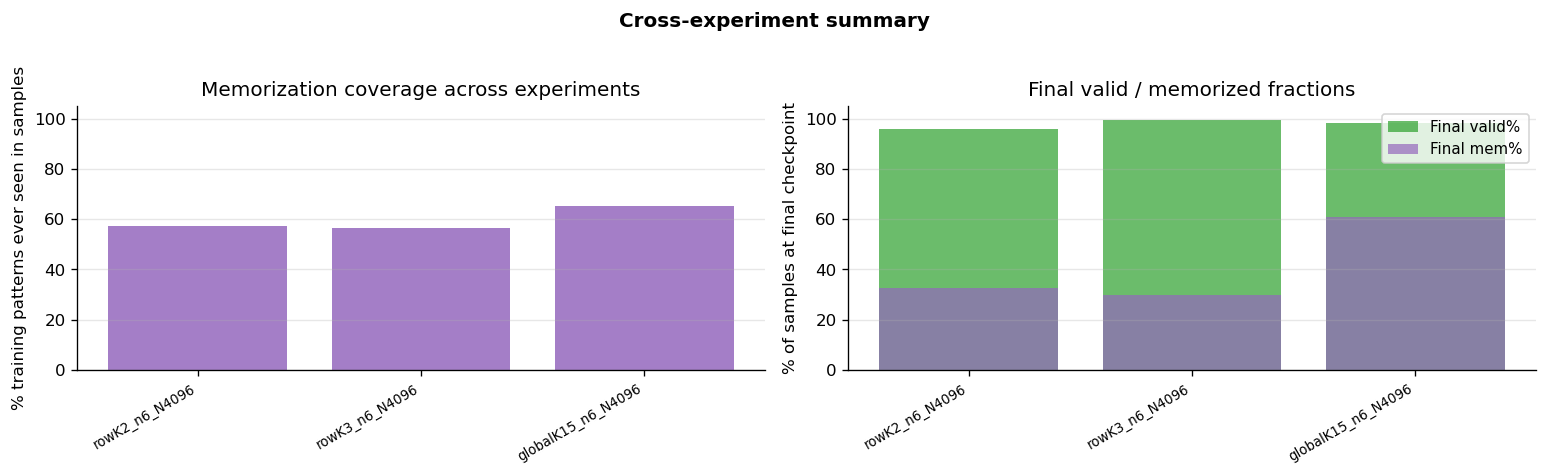

Saved: /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/rowK_analysis/evolution_cross_experiment_summary.png


In [13]:
# Cross-experiment bar chart: fraction of training patterns ever seen
if rows:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    labels = [r['exp'] for r in rows]
    x      = np.arange(len(labels))

    ax = axes[0]
    ax.bar(x, [r['seen_frac']*100 for r in rows], color='#9467bd', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('% training patterns ever seen in samples')
    ax.set_title('Memorization coverage across experiments')
    ax.set_ylim(0, 105); ax.grid(axis='y', alpha=0.3)

    ax = axes[1]
    ax.bar(x, [r['final_valid']*100 for r in rows], color='#2ca02c', alpha=0.7, label='Final valid%')
    ax.bar(x, [r['final_mem']*100  for r in rows], color='#9467bd', alpha=0.7, label='Final mem%')
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('% of samples at final checkpoint')
    ax.set_title('Final valid / memorized fractions')
    ax.set_ylim(0, 105); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Cross-experiment summary', fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    out = os.path.join(FIGDIR, 'evolution_cross_experiment_summary.png')
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')